# OpenML Python API Exercises (Sept 2026)
_Laith Agbaria and the OpenML Team_

This notebook can be used to exercise and experiment with the examples from the associated tutorial, it is mainly intended for the Leiden University course Automated Machine Learning and therefore has a focus on datasets.

The run requirements for this exercise notebook are similar to those of the associated tutorial, mainly a Python environment of version 3.10+ and the required packages.
___

## 1. Setting up

Begin by importing openml and other libraries you would like to use then optionally setup your server and API key, you are provided with an optional code block useful when interacting with the test server.

Throughout these exercises you would be asked to display different figures.

In [1]:
# [TODO] Your imports and configurations

# Imports
import openml
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Configs
openml.config.server = "https://www.openml.org/api/v1/xml"
openml.config.apikey = None
warnings.simplefilter(action="ignore", category=RuntimeWarning)


In [2]:
# Useful if you want to partially work on test server

from warnings import catch_warnings, simplefilter
from contextlib import contextmanager
from functools import wraps
import openml

# Allow use as "with in_test_server():"
@contextmanager
def in_test_server(api_key: str | None = None):
    with catch_warnings():
        simplefilter(action="ignore", category=UserWarning)
        openml.config.start_using_configuration_for_example()  # Preserve original API key and server
        if api_key is not None:
            openml.config.apikey = api_key
        try:
            yield
        finally:
            openml.config.stop_using_configuration_for_example()  # Undo temporary changes

# Allow use as a function decorator "@test_server_call"
def test_server_call(func = None, *, api_key: str | None = None):
    # Actual decorator function
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            with in_test_server(api_key):
                return func(*args, **kwargs)
        return wrapper
    
    if func is None:  # API key provided
        return decorator
    return decorator(func)

# Use examples
"""
print("Before:", openml.config.server)
with in_test_server():
    print("During:", openml.config.server)
print("After:", openml.config.server)


@test_server_call  # Alternatively: @test_server_call(api_key="normaluser")
def example():
    print("During:", openml.config.server)

print("Before:", openml.config.server)
example()
print("After:", openml.config.server)
"""
pass  # Only here to avoid the cell from printing the string

___
## 2. Datasets

Your objective in this section is to find a dataset which can be used in a Supervised Classification task.
To make things simple, the dataset should have:
 - Less than 10 classes,
 - Between 1.000 and 10.000 instances,
 - Majority class at most five times that of minority class,
 - None of the instances should have missing values.

In [3]:
# [TODO] List and filter datasets

columns = [
    "did",
    "name",
    "NumberOfClasses", 
    "NumberOfInstances",
    "MajorityClassSize",
    "MinorityClassSize",
    "NumberOfFeatures",
]
dataset_list = openml.datasets.list_datasets(output_format='dataframe')
filtered_list = dataset_list.query("NumberOfClasses <= 10 and " \
                                   "1000 <= NumberOfInstances <= 10000 and " \
                                   "NumberOfInstancesWithMissingValues == 0 and " \
                                   "MajorityClassSize <= 5*MinorityClassSize and " \
                                   "NumberOfFeatures <= 20")
display(filtered_list.head(n=20)[columns])

,did,name,NumberOfClasses,NumberOfInstances,MajorityClassSize,MinorityClassSize,NumberOfFeatures
18,18,mfeat-morphological,10.0,2000.0,200.0,200.0,7.0
23,23,cmc,3.0,1473.0,629.0,333.0,10.0
36,36,segment,7.0,2310.0,330.0,330.0,20.0
375,375,JapaneseVowels,9.0,9961.0,1614.0,782.0,15.0
679,679,rmftsa_sleepdata,4.0,1024.0,404.0,94.0,3.0
720,720,abalone,2.0,4177.0,2096.0,2081.0,9.0
725,725,bank8FM,2.0,8192.0,4885.0,3307.0,9.0
728,728,analcatdata_supreme,2.0,4052.0,3081.0,971.0,8.0
735,735,cpu_small,2.0,8192.0,5715.0,2477.0,13.0
737,737,space_ga,2.0,3107.0,1566.0,1541.0,7.0


Choose and load a dataset and begin to understand it, print the dataset information and read through the description.
Explore the data inside and examine it to prepare for visualization, find the target column, attribute names, categorical indicators, and some example entries.

In [4]:
# [TODO] Choose and load a specific dataset

dataset = openml.datasets.get_dataset(23)
print(dataset, end="\n"+'='*50+"\n")
print(dataset.description, end="\n"+'='*50+"\n")

target = dataset.default_target_attribute
X, y, categorical_indicator, attribute_names = dataset.get_data(target=target)
display(X)

OpenML Dataset
Name.........: cmc
Version......: 1
Format.......: ARFF
Upload Date..: 2014-04-06 23:21:03
Licence......: Public
Download URL.: https://openml.org/data/v1/download/23/cmc.arff
OpenML URL...: https://www.openml.org/d/23
# of features: None
**Author**: [Tjen-Sien Lim](limt@stat.wisc.edu) 
**Source**: [As obtained from UCI](https://archive.ics.uci.edu/ml/datasets/Contraceptive+Method+Choice)
**Please cite**: [UCI citation](https://archive.ics.uci.edu/ml/citation_policy.html)

1. Title: Contraceptive Method Choice
 
 2. Sources:
    (a) Origin:  This dataset is a subset of the 1987 National Indonesia
                 Contraceptive Prevalence Survey
    (b) Creator: Tjen-Sien Lim (limt@stat.wisc.edu)
    (c) Donor:   Tjen-Sien Lim (limt@stat.wisc.edu)
    (c) Date:    June 7, 1997
 
 3. Past Usage:
    Lim, T.-S., Loh, W.-Y. & Shih, Y.-S. (1999). A Comparison of
    Prediction Accuracy, Complexity, and Training Time of Thirty-three
    Old and New Classification Algorithms. M

,Wifes_age,Wifes_education,Husbands_education,Number_of_children_ever_born,Wifes_religion,Wifes_now_working%3F,Husbands_occupation,Standard-of-living_index,Media_exposure
0,24,2,3,3,1,1,2,3,0
1,45,1,3,10,1,1,3,4,0
2,43,2,3,7,1,1,3,4,0
3,42,3,2,9,1,1,3,3,0
4,36,3,3,8,1,1,3,2,0
...,...,...,...,...,...,...,...,...,...
1468,33,4,4,2,1,0,2,4,0
1469,33,4,4,3,1,1,1,4,0
1470,39,3,3,8,1,0,1,4,0
1471,33,3,3,4,1,0,2,2,0


Finally begin visual exploration by plotting the class distributions, check if there is a class imbalance.

Make sure to use the correct type of visualization for the data; line plots, bar plots, box plots, pair plots, etc..? Is it sequential or tabular for example.

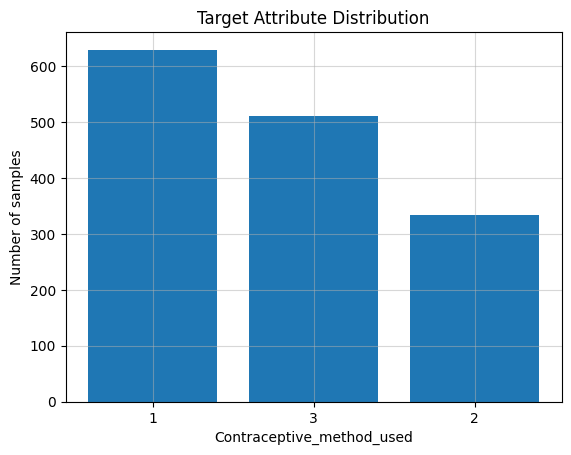

In [5]:
# [TODO] Visual target attribute distribution

target_counts = y.value_counts()

plt.bar(target_counts.index, target_counts.values)
plt.grid(True, alpha=0.5)

plt.xlabel(target)
plt.ylabel("Number of samples")
plt.title("Target Attribute Distribution")

plt.show()

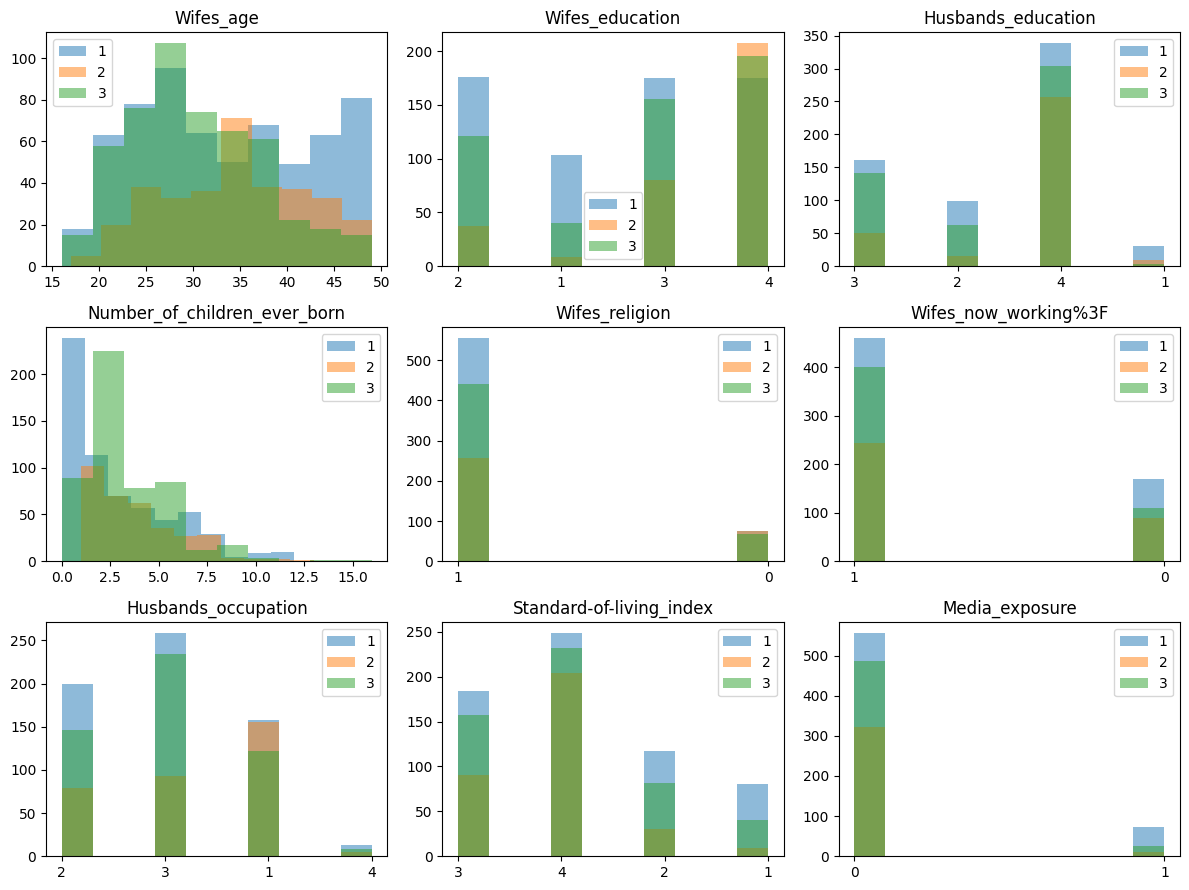

In [6]:
# [TODO] Visual data distributions

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i, column in enumerate(X.columns):
    ax = axes.flat[i]
    for cls in sorted(y.unique()):
        ax.hist(
            X.loc[y == cls, column],
            alpha=0.5,
            label=str(cls)
        )
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

___
## 3. Training a model with scikit-learn

Use Scikit-Learn to train a classification model on the dataset you have selected, measure the model performance on a split portion of the dataset.

In [7]:
# [TODO] Work with a scikit-learn model

# Create the model and split the dataset
split = int(len(X)*0.8)
indices = np.arange(len(X))
np.random.shuffle(indices)
train_indices, test_indices = indices[:split], indices[split:]

X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]
knn_parameters = {
    "n_neighbors": 3,
}
clf = KNeighborsClassifier(**knn_parameters)

# Train the model and measure performance
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
print("Accuracy = ", sum(y_pred == y_test) / len(y_test))

Accuracy =  0.5050847457627119


___
## 4. Tasks

Find a Supervised Classification task on OpenML for the dataset you selected, then load the training and test data split for reproducibility.

Show the task details, and display useful information.

This section might require an API key depending on the implementation, in which case you can use the test server.

In [11]:
# [TODO] Search through tasks and list viable ones
openml.config.start_using_configuration_for_example()
did = 23
task_type = "Supervised Classification"
task_list = openml.tasks.list_tasks(output_format='dataframe')
filtered_list = task_list.query(f"name == 'cmc' and task_type == '{task_type}'")
display(filtered_list)

/tmp/ipykernel_5708/4143257639.py:2: UserWarning: Switching to the test server https://test.openml.org/api/v1/xml to not upload results to the live server. Using the test server may result in reduced performance of the API!
  openml.config.start_using_configuration_for_example()


,tid,ttid,did,name,task_type,status,estimation_procedure,source_data,target_feature,MajorityClassSize,MinorityClassSize,NumberOfClasses,NumberOfFeatures,NumberOfInstances,NumberOfInstancesWithMissingValues,NumberOfMissingValues,NumberOfNumericFeatures,NumberOfSymbolicFeatures,evaluation_measures
73,73,TaskType.SUPERVISED_CLASSIFICATION,13,cmc,Supervised Classification,active,10-fold Crossvalidation,13,Contraceptive_method_used,629.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0,NaN
74,74,TaskType.SUPERVISED_CLASSIFICATION,13,cmc,Supervised Classification,active,5 times 2-fold Crossvalidation,13,Contraceptive_method_used,629.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0,NaN
75,75,TaskType.SUPERVISED_CLASSIFICATION,13,cmc,Supervised Classification,active,10 times 10-fold Crossvalidation,13,Contraceptive_method_used,629.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0,NaN
76,76,TaskType.SUPERVISED_CLASSIFICATION,13,cmc,Supervised Classification,active,Leave one out,13,Contraceptive_method_used,629.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0,NaN
77,77,TaskType.SUPERVISED_CLASSIFICATION,13,cmc,Supervised Classification,active,10% Holdout set,13,Contraceptive_method_used,629.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0,NaN
78,78,TaskType.SUPERVISED_CLASSIFICATION,13,cmc,Supervised Classification,active,33% Holdout set,13,Contraceptive_method_used,629.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0,NaN
1081,1081,TaskType.SUPERVISED_CLASSIFICATION,13,cmc,Supervised Classification,active,Test on Training Data,13,Contraceptive_method_used,629.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0,NaN
1218,1218,TaskType.SUPERVISED_CLASSIFICATION,13,cmc,Supervised Classification,active,20% Holdout (Ordered),13,Contraceptive_method_used,629.0,333.0,3.0,10.0,1473.0,0.0,0.0,2.0,8.0,NaN


In [12]:
# [TODO] Load a selected task and extract details

task = openml.tasks.get_task(78)
print(task)
repeats, folds, samples = task.get_split_dimensions()
print(f"Repeats: {repeats}, folds: {folds}, samples: {samples}")

OpenML Classification Task
Task Type Description: https://test.openml.org/tt/TaskType.SUPERVISED_CLASSIFICATION
Task ID..............: 78
Task URL.............: https://test.openml.org/t/78
Estimation Procedure.: holdout
Target Feature.......: Contraceptive_method_used
# of Classes.........: 3
Cost Matrix..........: Available
Repeats: 1, folds: 1, samples: 1


Use OpenML runs to train a similar model as before, compare the results with your original run.

In [13]:
# [TODO] Train a model using OpenML flows

run, flow = openml.runs.run_model_on_task(model=KNeighborsClassifier(), task=119, return_flow=True)
print(run)
openml.config.stop_using_configuration_for_example()

OpenML Run
Uploader Name...................: None
Metric..........................: None
Local Result - Accuracy (+- STD): 0.7312 +- 0.0000
Local Runtime - ms (+- STD).....: 14.8268 +- 0.0000
Run ID..........................: None
Task ID.........................: 119
Task Type.......................: None
Task URL........................: https://test.openml.org/t/119
Flow ID.........................: None
Flow Name.......................: sklearn.neighbors._classification.KNeighborsClassifier
Flow URL........................: None
Setup ID........................: None
Setup String....................: Python_3.12.3. Sklearn_1.9.1. NumPy_2.5.3. SciPy_1.18.1.
Dataset ID......................: 20
Dataset URL.....................: https://test.openml.org/d/20
